#  Использование предобученных моделей для классификации изображений

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/vision/0.16/transforms.html#v2-api-reference-recommended
* https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
* https://pytorch.org/vision/stable/models.html
* https://albumentations.ai/docs/getting_started/image_augmentation/

## Задачи для совместного разбора

1\. Загрузите предобученную модель из `torchvision`. Познакомьтесь с ее архитектурой. Заморозьте веса нескольких слоев.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию из `torchvision`, cоздайте модель `vgg16` и загрузите предобученные веса `IMAGENET1K_V1`. Выведите на экран структуру модели, количество слоев и количество настраиваемых (`requires_grad==True`) параметров модели. 

- [ ] Проверено на семинаре

In [2]:
import os
import random
import time
import zipfile

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import VGG16_Weights, vgg16

torch.manual_seed(42)
random.seed(42)

def count_layers(model):
    return sum(1 for _ in model.modules()) - 1

def count_trainable_params(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            logits = model(images)
            correct += (logits.argmax(dim=1) == targets).sum().item()
            total += targets.size(0)
    return correct / total

def train_model(model, train_loader, test_loader, epochs=2, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda param: param.requires_grad, model.parameters()), lr=lr)
    history = {"loss": [], "train_acc": [], "test_acc": []}
    model.to(device)

    for _ in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, targets in train_loader:
            images = images.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * targets.size(0)
            correct += (logits.argmax(dim=1) == targets).sum().item()
            total += targets.size(0)
        history["loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)
        history["test_acc"].append(evaluate(model, test_loader))

    return history

def plot_history(history):
    plt.figure(figsize=(6, 4))
    plt.plot(history["loss"])
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history["train_acc"], label="train")
    plt.plot(history["test_acc"], label="test")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

weights = VGG16_Weights.IMAGENET1K_V1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = vgg16(weights=weights)
for param in model.features[:10].parameters():
    param.requires_grad = False

model = model.to(device)

print(model)
print(f"layers: {count_layers(model)}")
print(f"trainable params: {count_trainable_params(model)}")


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\alexm/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 73.3MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

<p class="task" id="2"></p>

2\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%. 

К обучающему датасету примените следующее преобразование: приведите картинки к размеру 256x256, затем обрежьте по центру с размером 224х224, затем переведите изображения в тензор и нормализуйте значения интенсивности пикселей (`mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)`).

К тестовому датасету примените преобразование `VGG16_Weights.IMAGENET1K_V1.transforms`.

- [ ] Проверено на семинаре

In [3]:
class CatBreeds(datasets.ImageFolder):
    pass

extract_dir = os.path.join(os.getcwd(), "data")
zip_path = os.path.join(extract_dir, "cat_breeds_4.zip")
root_dir = os.path.join(extract_dir, "cat_breeds_4")

if not os.path.isdir(root_dir):
    with zipfile.ZipFile(zip_path) as zip_ref:
        zip_ref.extractall(extract_dir)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

test_transform = VGG16_Weights.IMAGENET1K_V1.transforms()

full_dataset = CatBreeds(root_dir, transform=train_transform)
num_images = len(full_dataset)
num_classes = len(full_dataset.classes)
train_size = int(0.8 * num_images)
test_size = num_images - train_size
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(num_images, generator=generator).tolist()
train_indices = indices[:train_size]
test_indices = indices[train_size:]

train_dataset = Subset(CatBreeds(root_dir, transform=train_transform), train_indices)
test_dataset = Subset(CatBreeds(root_dir, transform=test_transform), test_indices)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"images: {num_images}")
print(f"train size: {train_size}")
print(f"test size: {test_size}")
print(f"classes: {num_classes}")


images: 4000
train size: 3200
test size: 800
classes: 4


<p class="task" id="3"></p>

3\. Заморозьте все веса модели из предыдущего задания. Замените последний слой `Linear` классификатора на новый слой, соответствующий задаче. После изменения последнего слоя выведите на экран количество настраиваемых (`requires_grad==True`) параметров модели. Решите задачу, используя модель с замороженными весами и изменнным последним слоем. 

Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. 

- [ ] Проверено на семинаре

trainable params: 16388


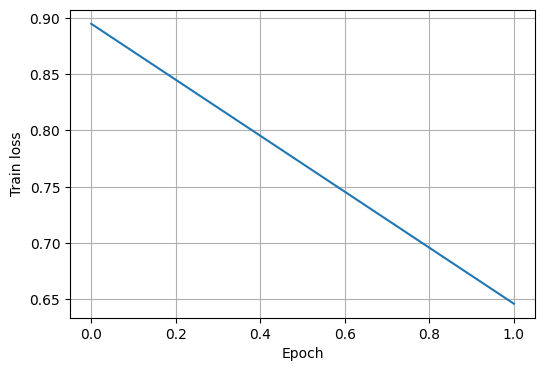

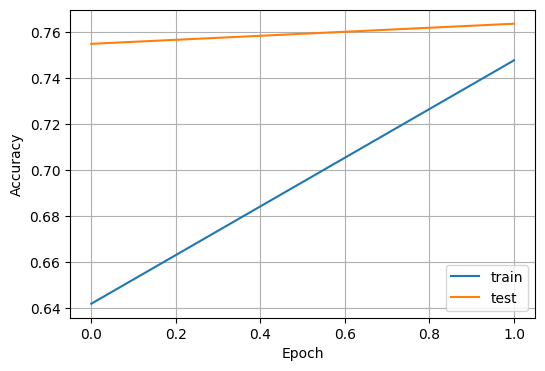

train accuracy: 0.7478
test accuracy: 0.7638
time: 41.7 s


In [4]:
model = vgg16(weights=weights)
for param in model.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model = model.to(device)

print(f"trainable params: {count_trainable_params(model)}")

frozen_start_time = time.time()
frozen_history = train_model(model, train_loader, test_loader, epochs=2, lr=1e-4)
frozen_elapsed = time.time() - frozen_start_time

plot_history(frozen_history)
print(f"train accuracy: {frozen_history['train_acc'][-1]:.4f}")
print(f"test accuracy: {frozen_history['test_acc'][-1]:.4f}")
print(f"time: {frozen_elapsed:.1f} s")


<p class="task" id="4"></p>

4\. Повторите решение предыдущей задачи, заморозив все сверточные слои, кроме последнего (слои классификатора не замораживайте). Сравните качество полученного решения и решения из предыдущей задачи, а также время, затраченное на обучения моделей. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

trainable params: 121922052


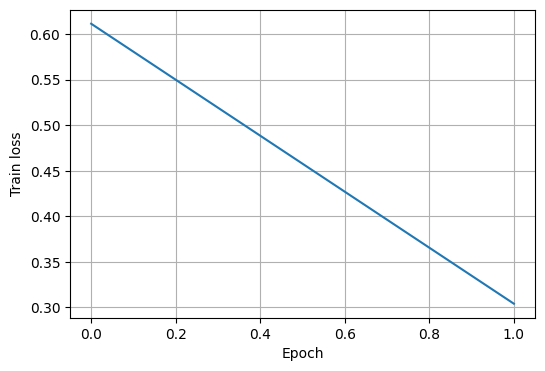

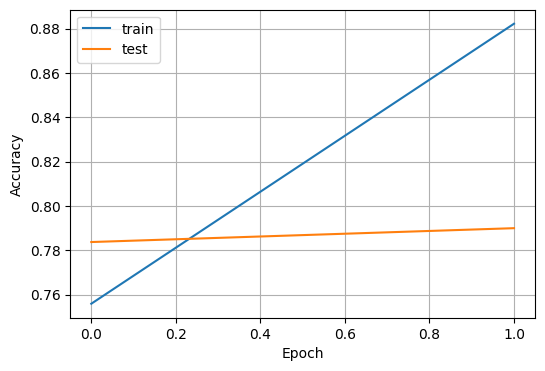

train accuracy: 0.8822
test accuracy: 0.7900
time: 50.6 s
previous test accuracy: 0.7638
current test accuracy: 0.7900
previous time: 41.7 s
current time: 50.6 s


In [5]:
model = vgg16(weights=weights)
for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[28].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model = model.to(device)

print(f"trainable params: {count_trainable_params(model)}")

partial_start_time = time.time()
partial_history = train_model(model, train_loader, test_loader, epochs=2, lr=1e-4)
partial_elapsed = time.time() - partial_start_time

plot_history(partial_history)
print(f"train accuracy: {partial_history['train_acc'][-1]:.4f}")
print(f"test accuracy: {partial_history['test_acc'][-1]:.4f}")
print(f"time: {partial_elapsed:.1f} s")
print(f"previous test accuracy: {frozen_history['test_acc'][-1]:.4f}")
print(f"current test accuracy: {partial_history['test_acc'][-1]:.4f}")
print(f"previous time: {frozen_elapsed:.1f} s")
print(f"current time: {partial_elapsed:.1f} s")


<p class="task" id="5"></p>

5\. Повторите решение задачи 3, расширив обучающий набор данных при помощи преобразований из `torchvision`, изменяющих изображение (повороты, изменение интенсивности пикселей, обрезание и т.д.). При оценке модели на тестовой выборке данные преобразования применяться не должны. Решение о том, сколько и каких слоев модели будет обучаться, примите самостоятельно. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

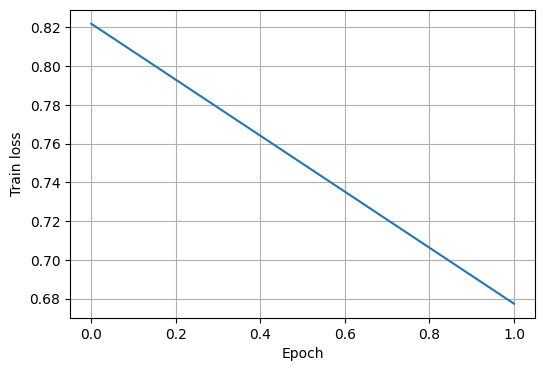

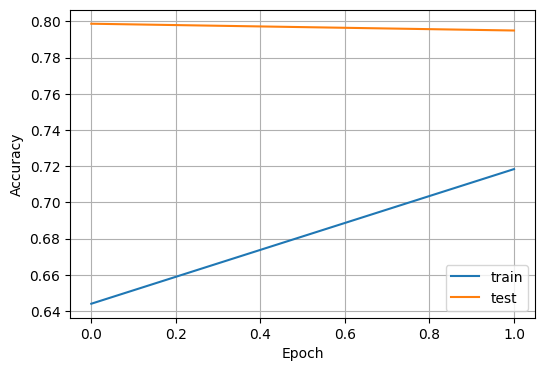

train accuracy: 0.7184
test accuracy: 0.7950
time: 70.3 s


In [6]:
aug_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

aug_train_dataset = Subset(CatBreeds(root_dir, transform=aug_train_transform), train_indices)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=16, shuffle=True)

model = vgg16(weights=weights)
for param in model.parameters():
    param.requires_grad = False

for param in model.features[28].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model = model.to(device)

start_time = time.time()
history = train_model(model, aug_train_loader, test_loader, epochs=2, lr=1e-4)
elapsed = time.time() - start_time

plot_history(history)
print(f"train accuracy: {history['train_acc'][-1]:.4f}")
print(f"test accuracy: {history['test_acc'][-1]:.4f}")
print(f"time: {elapsed:.1f} s")


## Обратная связь
- [ ] Хочу получить обратную связь по решению